In [ ]:
pip install pygad

Parameters of the best solution : [ 0.63687441  4.52188558 -2.68042066  2.83790302  0.9196718 ]
Fitness value of the best solution : 1492.309813347917


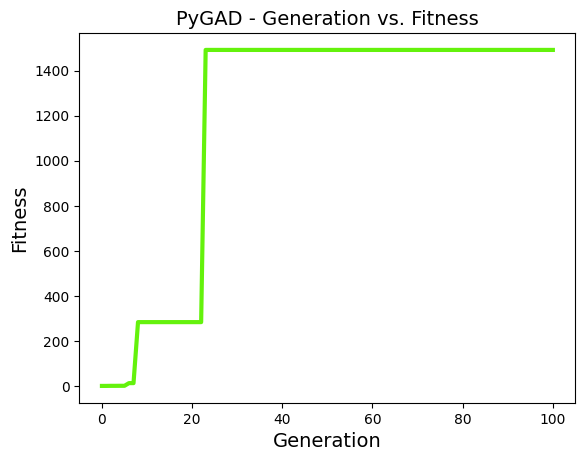

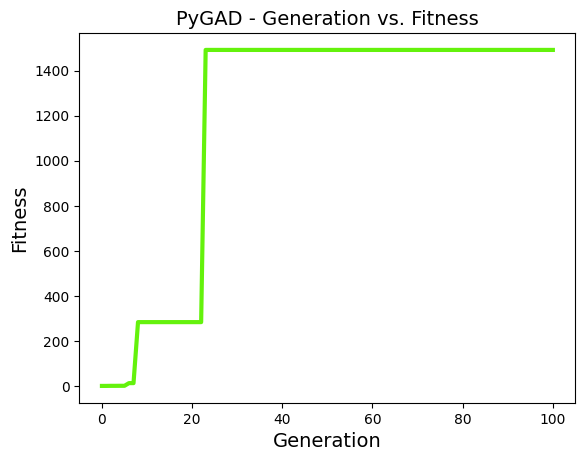

In [ ]:
import pygad
import numpy

inputs = [0.4,1,0,7,8]
desired_output = 32

def fitness_func(solution, solution_idx):
    output = numpy.sum(solution*inputs)
    fitness = 1.0 / (numpy.abs(output - desired_output) + 0.000001)

    return fitness


# To this:
def fitness_func(ga_instance, solution, solution_idx):
    output = numpy.sum(solution * inputs)
    fitness = 1.0 / (numpy.abs(output - desired_output) + 0.000001)
    return fitness



ga_instance = pygad.GA(num_generations=100,
                       sol_per_pop=10,
                       num_genes=len(inputs),
                       num_parents_mating=2,
                       fitness_func=fitness_func,
                       mutation_type="random",
                       mutation_probability=0.6)

ga_instance.run()


# Access the best solution found
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Parameters of the best solution : {solution}")
print(f"Fitness value of the best solution : {solution_fitness}")

ga_instance.plot_fitness()

# Carga de Datos

In [ ]:
from sklearn.datasets import load_breast_cancer

diabetes = load_breast_cancer(as_frame = True)
data = diabetes['data']
target = diabetes['target']

data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
from sklearn.model_selection import train_test_split

seed = 1234
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=seed)

# Creación de la red neuronal

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()
#model.add(Input(x_train.shape[1]))
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(8, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

# Optimización de red neuronal con algoritmo genético

Ahora que tengo el modelo creado, es cuando entra en acción la ejecución del modelo usando el algoritmo genético como optimizador del modelo.

Para ello, los pasos son los siguientes:

*   Crear un modelo optimizador en base a nuestro modelo optimizador.
*   Dada la solución propuesta por el algoritmo genético, implementarla en nuestra red neuronal
*   Hacer la predicción con el modelo y calcular el fitness de la predicción.
Así pues, lo primero de todo es crear un algoritmo genético compatible con Keras. Para ello, la librería pygad cuenta con la función KerasGA.



Esta función únicamente cuenta con dos parámetros:

model: modelo de Keras que queremos que optimice.
num_solutions: indica el número de soluciones a usar en la población. Cada una de estas soluciones contará con unos parámetros del modelo diferentes.
Así pues, creamos el modelo optimizador.

In [ ]:
from pygad import kerasga

keras_ga = kerasga.KerasGA(
    model = model,
    num_solutions = 15
)

In [ ]:
from keras.losses import BinaryCrossentropy

def fitness_func(ga_instance, solution, solution_idx):
    global model

    # Convertir el cromosoma (vector) en matrices de pesos compatibles con Keras
    weights = kerasga.model_weights_as_matrix(
        model=model,
        weights_vector=solution
    )

    # Colocar esos pesos en la red
    model.set_weights(weights=weights)

    # Predicción sobre entrenamiento
    prediction = model.predict(x_train, verbose=0)

    # Queremos minimizar la entropía cruzada.
    # Como PyGAD maximiza fitness, usamos su inverso.
    entropy = BinaryCrossentropy()(y_train, prediction)
    fitness = 1.0 / (float(entropy.numpy()) + 0.0001)

    return fitness


In [ ]:
fitness_evol = []

def callback_generation(ga_instance):
  global fitness_evol
  fitness_evol.append(ga_instance.best_solution()[1])
  generation = ga_instance.generations_completed

  if generation % 1 == 0:
    print(f"Generation {generation}. Fitness: {ga_instance.best_solution()[1]}")

In [ ]:
from pygad import GA

num_generations = 5
num_parents_mating = 5
initial_population = keras_ga.population_weights

ga_optimizer = GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    initial_population=initial_population,
    fitness_func=fitness_func,
    on_generation=callback_generation
)

ga_optimizer.run()


TypeError: 'int' object is not subscriptable

In [ ]:
import seaborn as sns

sns.lineplot(
    x = range(len(fitness_evol)),
    y = fitness_evol
)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# La red tiene UNA neurona sigmoide, por lo que devuelve probabilidades.
pred = model.predict(x_test, verbose=0).ravel()

# Convertimos probabilidad a clase usando umbral 0.5.
classes = (pred >= 0.5).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, classes))
print("Accuracy:", accuracy_score(y_test, classes))


# Problemas de optimización con algoritmos genéticos en Python

In [ ]:
margin = np.array([2, 2.5])
material_consumption = np.array([2, 3])
material_max = 500

def fitness_func(ga_instance, solution, solution_idx):
    # Se suman 50 porque la solución representa incrementos respecto a una base.
    solution_added = solution + 50

    calculated_margin = np.sum(solution_added * margin)
    material_consumed = np.sum(solution_added * material_consumption)

    # Penalización: si viola la restricción de material, fitness = 0.
    if material_consumed > material_max:
        return 0

    return calculated_margin

# Comprobación manual (llamamos con ga_instance=None y solution_idx=None)
print(f"Fitness for correct scenario: {fitness_func(None, np.array([0, 0]), None)}")
print(f"Fitness for incorrect scenario: {fitness_func(None, np.array([0, 1]), None)}")


In [ ]:
ga_instance = pygad.GA(num_generations=1000,
                       sol_per_pop=10,
                       num_genes=2,
                       num_parents_mating=2,
                       fitness_func=fitness_func,
                       mutation_type="random",
                       mutation_probability=0.6
                       )

ga_instance.run()

ga_instance.plot_fitness()

In [ ]:
ga_instance.best_solution()[0] + 50

## Cómo programar un algoritmo genético desde cero en Python
Si se requiere programar un algoritmo genético desde cero, se tiene que:

*   Crear una población de n individuos.


Codificar las diferentes maneras en las que se genera descendencia.
Así pues, se empieza por: definir una población. Para ello, vamos a incluir una cuestión que considero ayuda bastante a la hora de converger, que consiste en definir una serie de límites que pueden recibir cada uno de los valores clave.

Así pues, lo primero de todo es crear dicha población.

Programar la creación de una población de un algoritmo genético
Para programar el algoritmo genético en Python, usaremos una clase. Así pues, la creación de la población se hará en la inicialización de dicha clase.

Dicho esto, para facilitar que el algoritmo converga de una forma más rápida, voy a crear dos tipos de inicialización de la población:

Inicialización aleatoria de los alelos. Simplemente se crearán valores aleatorios que se deberán ir optimizando. Este tipo de inicialización se hará si el parámetro gene_limits es nulo.
Inicialización limitada ed los alelos. Consiste en incluir unos límites para cada uno de nuestros alelos, de tal forma que lo valores se incialicen de forma aleatoria dentro de dichos límites. Este tipo de inicialización se hará si el parámetro gene_limits no es nulo.
Dicho esto, programo la inicialización aleatoria de la población:

In [ ]:
import numpy as np


class GeneticAlgorithm:
  def __init__(self, n_variables, n_genes, random_state = None, gene_limits = None):

    self.n_variables = n_variables
    self.n_genes = n_genes
    self.gene_limits = gene_limits
    self.random_state = random_state

    # Create the population
    if self.gene_limits is not None:

      # Check that both vectors have the same length
      assert len(self.gene_limits) == self.n_variables

      limits = [np.random.uniform(limit[0], limit[1], self.n_genes)
        for limit in self.gene_limits]

    else:
      limits = [np.random.random(self.n_genes)
        for limit in range(self.n_variables)]

    # Convert list of limits to list of solutions
    self.population = list(zip(*limits))

ga = GeneticAlgorithm(
    n_variables = 2,
    n_genes = 10
)

ga.population

# Calcular el fitness del algoritmo genético

Partiendo de una población, tenese tiene que permitir a nuestro algoritmo genético recibir una función de fitness. Además, internamente usar dicha función de fitness para calcular el fitness de cada una de las soluciones.

Así pues, se ampliara el código anterior, incluyendo un nuevo parámetro fitness_func el cual recibe como input una solución y devuelve un valor de fitness.

Asimismo, crear un método llamado get_fitness_scores, que devuelva el fitness score de la solución actual. Esto facilitará el uso del fitness score a lo largo del algoritmo.

Dicho esto, extendamos el código anterior incluyendo el fitness:

In [ ]:
import numpy as np
import inspect

class GeneticAlgorithm:
  def __init__(
      self, n_variables, n_genes, mutation_type = 'random', random_state = None,
      gene_limits = None, fitness_func = None):

    assert mutation_type in ['random']

    self.n_variables = n_variables
    self.n_genes = n_genes
    self.gene_limits = gene_limits
    self.mutation_type = mutation_type
    self.random_state = random_state
    self.fitness_func = fitness_func

    # Create the population
    if self.gene_limits is not None:

      # Check that both vectors have the same length
      assert len(self.gene_limits) == self.n_variables

      limits = [np.random.uniform(limit[0], limit[1], self.n_genes)
        for limit in self.gene_limits]

    else:
      limits = [np.random.random(self.n_genes)
        for limit in range(self.n_variables)]

    # Convert list of limits to list of solutions
    self.population = list(zip(*limits))

  def get_fitness_scores(self):
    scores = [self.fitness_func(ind) for ind in self.population]
    return np.array(scores)

# A partir de aquí usamos NUESTRA clase, no PyGAD; por eso la función recibe solo solution.
def fitness_func(solution):
  solution = np.array(solution)
  solution_added = solution + 50
  calculated_margin = np.sum(solution_added*margin)
  material_consumed = np.sum(solution_added*material_consumption)

  if material_consumed> material_max:
    return 0

  else:
    return calculated_margin

ga = GeneticAlgorithm(
    n_variables = 2,
    n_genes = 10,
    fitness_func= fitness_func
)

fitness_scores = ga.get_fitness_scores()
fitness_scores

# Cómo programar la selección de individuos de un algoritmo genético
Una vez podemos evaluar la función, vamos a crear el sistema de selección de nuestros mejores candidatos.

En este sentido, vamos a crear un sistema que permita realizar diferentes dos tipos de procesos de selección: el método de ranking y el método de torneo.

Para el método del ranking simplemente tenemos que devolver los índices de aquella población con los k mejores resultados en términos de fitness. Como podemos ver, se añade a nuestro algoritmo un nuevo parámetro, que se refiere al número de individuios elegidos para obtener descendencia.

Respecto al torneo, crearemos tantas parejas aleatorias como número de genes de población queremos y de cada pareja elegiremos al valor más alto.

Veamos nuestros sistemas de selección en acción:

In [ ]:
def ranking_selection(scores, k):
    if k is None:
        raise ValueError('K must not be None if ranking is selected.')

    # Índices de los k individuos con mayor fitness
    ind = np.argsort(scores)[-k:]
    return ind

def tournament_selection(scores, k, n_candidates=3):
    if k is None:
        raise ValueError('K must not be None if tournament is selected.')

    if n_candidates is None:
        n_candidates = 3

    winners = []

    for _ in range(k):
        # Elegimos candidatos al azar
        candidates = np.random.choice(
            len(scores),
            size=min(n_candidates, len(scores)),
            replace=False
        )

        # El ganador es el candidato con mayor fitness
        winner_local = np.argmax(scores[candidates])
        winners.append(candidates[winner_local])

    return np.array(winners)

def gene_selection(scores, type, k, n_candidates=None):
    if type not in ['ranking', 'tournament']:
        raise ValueError('Type should be ranking or tournament')

    if type == 'ranking':
        return ranking_selection(scores, k)

    return tournament_selection(scores, k, n_candidates)


ranking_result = gene_selection(
    scores=fitness_scores,
    type='ranking',
    k=3
)

tournament_result = gene_selection(
    scores=fitness_scores,
    type='tournament',
    k=3,
    n_candidates=3
)

print(f"""
Ranking selection results: {ranking_result}
Tournament selection results: {tournament_result}
""")


# Cómo programar la generación de descendencia

In [ ]:
def crossover(parent1, parent2, crossover_type):

  # Check crossover type
  if crossover_type not in ['uniform', 'one_point']:
    raise ValueError('crossover_type should be one of uniform, one_point or multi_point')

  if crossover_type == 'one_point':
    index = np.random.choice(range(len(parent1)))
    children = [parent2[:index] + parent1[index:], parent1[:index] + parent2[index:]]

  elif crossover_type == 'uniform':
    parents = list(zip(*[parent1,parent2]))
    children1 = tuple([np.random.choice(element) for element in parents])
    children2 = tuple([np.random.choice(element) for element in parents])
    children = [children1, children2]
  else:
    pass

  return children

children_uniform = crossover(
    ga.population[0],
    ga.population[1],
    crossover_type = 'uniform'
    )

children_onepoint = crossover(
    ga.population[0],
    ga.population[1],
    crossover_type = 'one_point'
    )

print(f"""
Children Uniform: {children_uniform}
Children One Point: {children_onepoint}
""")

In [ ]:
def mutation(individual, mutation_type):

  if mutation_type not in ['bitstring', 'shrink']:
    raise ValueError('mutation_type should be one of bitstring or shrinkg')

  # Get index of individual to modify
  index = np.random.choice(len(individual))

  # Convert individual to list so that can be modified
  individual_mod = list(individual)

  if mutation_type == 'bitstring':
    individual_mod[index] = 1 - individual_mod[index]

  else:
    individual_mod[index] = individual_mod[index] + np.random.rand()

  # Convert indivudal to tuple
  individual = tuple(individual_mod)

  return individual

mutation_bitstring = mutation(ga.population[0], mutation_type = 'bitstring')
mutation_shrink = mutation(ga.population[0], mutation_type = 'shrink')


print(f"""
Mutation bitstring: {mutation_bitstring}
Mutation shrink: {mutation_shrink}
""")

# Programar la evolución en los algoritmos genéticos
De cara a crear la evolución de nuestro algoritmo genético, simplemente se debe  poner en conjunto todos los puntos anteriores, lo cual lo haré con el método optimize.

En este sentido, he incluido ciertas cuestiones, relevantes, como el valor best_fitness_evolution el cual va guardando el mejor resultado de fitness de cada generación.

Asimismo, también he creado un método, llamado view_fitness_evolution, el cual permite visualizar la evolución del mejor fitness obtenido, tal como hemos visto previamente con PyGAD.

Así pues, el código final para generar un algoritmo genético en Python es el siguiente:

In [ ]:
import numpy as np
import inspect
from tqdm import tqdm
import matplotlib.pyplot as plt

class GeneticAlgorithm:
  def __init__(
      self,
      n_variables,
      n_genes,
      n_iterations,
      transformation_type = None,
      mutation_type = None,
      crossover_type = None,
      gene_selection_type = None,
      n_selected_individuals = None,
      n_candidates = None,
      random_state = None,
      gene_limits = None,
      fitness_func = None
      ):

    # Make validations
    if transformation_type not in ['mutation', 'transformation']:
      raise ValueError('transformation_type should be one of mutation or transformation.')

    self.n_variables = n_variables
    self.n_genes = n_genes
    self.gene_limits = gene_limits
    self.transformation_type = transformation_type
    self.mutation_type = mutation_type
    self.random_state = random_state
    self.fitness_func = fitness_func
    self.n_iterations = n_iterations
    self.gene_selection_type = gene_selection_type
    self.n_selected_individuals = n_selected_individuals
    self.n_candidates = n_candidates
    self.crossover_type = crossover_type
    self.best_fitness_evolution = []

    # Asserts
    # Check that fitness function is a function
    assert callable(fitness_func)

    # Create the population
    if self.gene_limits is not None:

      # Check that both vectors have the same length
      assert len(self.gene_limits) == self.n_variables

      limits = [np.random.uniform(limit[0], limit[1], self.n_genes)
        for limit in self.gene_limits]

    else:
      limits = [np.random.random(self.n_genes)
        for limit in range(self.n_variables)]

    # Convert list of limits to list of solutions
    self.population = np.array(list(zip(*limits)))

  def get_fitness_scores(self):
    scores = [self.fitness_func(ind) for ind in self.population]
    scores = np.array(scores)
    return scores

  def __append_best_score(self, scores):
    best_score = np.max(scores)
    self.best_fitness_evolution.append(best_score)
    return 'Ok'


  def __ranking_selection(self, k):
      if k is None:
        raise ValueError('K must not be None if ranking is selected.')

      scores = self.get_fitness_scores()
      return np.argsort(scores)[-k:]

  def __tournament_selection(self, k, n_candidates):
    if n_candidates is None:
      n_candidates = 3

    scores = self.get_fitness_scores()
    winners = []

    for _ in range(k):
      candidates = np.random.choice(
          len(scores),
          size=min(n_candidates, len(scores)),
          replace=False
      )
      winner_local = np.argmax(scores[candidates])
      winners.append(candidates[winner_local])

    return np.array(winners)

  def gene_selection(self, gene_selection_type, k, n_candidates = None):

    if gene_selection_type not in ['ranking','tournament']:
      raise ValueError('Type should be ranking or tournament')

    if gene_selection_type == 'ranking':
      ind = self.__ranking_selection(k)
    elif gene_selection_type == 'tournament':
      ind = self.__tournament_selection(k, n_candidates)
    else:
      pass

    return ind

  def __crossover(self, parent1, parent2, crossover_type):

    # Check crossover type
    if crossover_type not in ['uniform', 'one_point']:
      raise ValueError('crossover_type should be one of uniform, one_point or multi_point')

    if crossover_type == 'one_point':
      index = np.random.choice(range(len(parent1)))
      children = parent2[:index] + parent1[index:], parent1[:index] + parent2[index:]

    elif crossover_type == 'uniform':
      parents = list(zip(*[parent1,parent2]))
      children1 = tuple([np.random.choice(element) for element in parents])
      children2 = tuple([np.random.choice(element) for element in parents])
      children = children1, children2
    else:
      pass

    return children


  def __mutation(self, individual, mutation_type):

    if mutation_type not in ['bitstring', 'shrink']:
      raise ValueError('mutation_type should be one of bitstring or shrinkg')

    # Get index of individual to modify
    index = np.random.choice(len(individual))

    # Convert individual to list so that can be modified
    individual_mod = list(individual)

    if mutation_type == 'bitstring':
      individual_mod[index] = 1 - individual_mod[index]

    else:
      individual_mod[index] = individual_mod[index] + np.random.rand()

    # Convert indivudal to tuple
    individual = tuple(individual_mod)

    return individual

  def optimize(self):

    for i in tqdm(range(self.n_iterations)):

      # Calculate fitness score
      scores = self.get_fitness_scores()

      # Append best score
      _ = self.__append_best_score(scores)

      # Make Selection
      selected_genes = self.gene_selection(
          gene_selection_type = self.gene_selection_type,
          k = self.n_selected_individuals,
          n_candidates = self.n_candidates
          )

      # Get selected population
      selected_population = self.population[selected_genes.tolist()]


      # Make transformations (mutation/crossover)
      if self.transformation_type == 'mutation':
        transformed_genes_index = np.random.choice(
            range(len(selected_population)),
            self.n_genes
            )


        new_population = [self.__mutation(selected_population[i], self.mutation_type)
          for i in transformed_genes_index]

      else:
        # Get pairs of parents
        parents_pairs = np.random.choice(
            selected_genes,
            (int(self.n_genes/2),2)
            )

        # For each pair, make crossover
        new_population = [self.__crossover(self.population[parents[0]],
                                           self.population[parents[1]],
                                           crossover_type=self.crossover_type
                                           )
          for parents in parents_pairs]

        # Unnest population
        new_population = [child for children in new_population for child in children]

      # Set new population as population
      self.population = np.array(new_population)

    # When n_iterations are finished, fitness score
    scores = self.get_fitness_scores()

    # Append best score
    _ = self.__append_best_score(scores)

    # Get the result where the result is the best
    # Como el algoritmo maximiza fitness, elegimos el índice del valor máximo.
    best_score_ind = np.argmax(scores)

    best_solution = self.population[best_score_ind]
    best_score = scores[best_score_ind]

    return (best_solution, best_score)

  def view_fitness_evolution(self):
    plt.plot(
        range(len(self.best_fitness_evolution)),
        self.best_fitness_evolution
    )

In [ ]:
ga = GeneticAlgorithm(
  n_variables = 2,
  n_genes = 10,
  n_iterations = 50,
  transformation_type = 'mutation', #transformation
  mutation_type = 'shrink',
  #crossover_type = 'uniform',
  gene_selection_type = 'ranking',
  n_selected_individuals = 3,
  #n_candidates = None,
  #random_state = None,
  #gene_limits = None,
  fitness_func = fitness_func
  )

print(ga.optimize())
ga.view_fitness_evolution()

In [ ]:
ga = GeneticAlgorithm(
  n_variables = 2,
  n_genes = 10,
  n_iterations = 50,
  transformation_type = 'transformation',
  crossover_type = 'uniform',
  gene_selection_type = 'ranking',
  n_selected_individuals = 3,
  fitness_func = fitness_func
  )

print(ga.optimize())
ga.view_fitness_evolution()

## Resumen para estudiar esta práctica

Un **algoritmo genético (AG)** es un método de optimización inspirado en la evolución biológica.

1. **Población:** conjunto de soluciones candidatas.
2. **Cromosoma/individuo:** una solución completa.
3. **Gen:** cada variable que forma una solución.
4. **Fitness:** función que mide qué tan buena es una solución.
5. **Selección:** se eligen individuos con buen fitness para reproducirse.
6. **Crossover:** combina información de dos padres para crear descendencia.
7. **Mutación:** modifica aleatoriamente algunos genes y ayuda a conservar diversidad.
8. **Nueva generación:** los descendientes sustituyen total o parcialmente a la población.
9. El proceso se repite hasta alcanzar un número de generaciones o una solución suficientemente buena.

### Idea clave de la práctica

PyGAD **maximiza** la función de fitness. Si nuestro problema natural consiste en minimizar un error, podemos convertirlo en algo que se maximice, por ejemplo:

\[
fitness = \frac{1}{error + \varepsilon}
\]

Así, menor error implica mayor fitness.

En la red neuronal de esta práctica, el algoritmo genético no usa descenso por gradiente para encontrar los pesos: cada individuo representa una posible colección de pesos y PyGAD busca cuáles producen menor `BinaryCrossentropy`.

En el segundo problema existe además una **restricción** de material. Las soluciones que exceden el máximo reciben fitness 0, por lo que quedan desfavorecidas durante la evolución.

### Diferencia entre selección, crossover y mutación

- **Selección:** decide quiénes pueden reproducirse.
- **Crossover:** mezcla genes de dos padres.
- **Mutación:** cambia aleatoriamente genes de un individuo.
- **Fitness:** no modifica individuos; solamente los evalúa.

### Frase corta para explicar el algoritmo en examen

> Un algoritmo genético mantiene una población de soluciones candidatas y, generación tras generación, favorece las de mayor fitness mediante selección, crossover y mutación hasta aproximarse a una solución óptima.


# Conclusión
Sin duda alguna los algoritmos genéticos son modelos de optimización muy utilizados que deben estar entre las herramientas que usa todo científico de datos.

Se aplicó un algoritmo genético, cómo funciona y cómo usarlo de forma sencilla en Python, tanto para modelos de optimización como para optimización de hiperparámetros.

Además, has podido ver cómo se programa un algoritmo genético desde cero en Python, siviendo para asentar el funcionamiento de este algoritmo.

